# Phase 1 — Preprocessing FD004

**FD004 = le plus difficile des 4 datasets**

| | FD001 | FD002 | FD003 | FD004 |
|--|-------|-------|-------|-------|
| Conditions opérationnelles | 1 | 6 | 1 | **6** |
| Modes de panne | 1 | 1 | 2 | **2** |
| Moteurs train | 100 | 260 | 100 | **248** |
| Settings | supprimés | gardés | supprimés | **gardés** |
| Difficulté | ⭐ | ⭐⭐ | ⭐⭐ | ⭐⭐⭐ |

**FD004 combine tout : 6 conditions + 2 modes de panne**

## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json, os, joblib
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
print(' Imports OK')

 Imports OK


In [2]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR    = '/content/drive/MyDrive/industrial-ai-platform'
DATA_DIR    = f'{BASE_DIR}/Data/cmapss'
OUTPUT_DIR  = f'{BASE_DIR}/preprocessing_FD004'
CONFIG_PATH = f'{BASE_DIR}/feature_config.json'

os.makedirs(OUTPUT_DIR, exist_ok=True)

TRAIN_PATH = f'{DATA_DIR}/train_FD004.txt'
TEST_PATH  = f'{DATA_DIR}/test_FD004.txt'
RUL_PATH   = f'{DATA_DIR}/RUL_FD004.txt'

print(f'Chemins définis')
print(f'Output : {OUTPUT_DIR}')

Mounted at /content/drive
Chemins définis
Output : /content/drive/MyDrive/industrial-ai-platform/preprocessing_FD004


## 2. Chargement des données

In [3]:
COLUMNS = [
    'unit_id', 'time_cycle',
    'op_setting_1', 'op_setting_2', 'op_setting_3',
    *[f'sensor_{i:02d}' for i in range(1, 22)]
]

df_train = pd.read_csv(TRAIN_PATH, sep=r'\s+', header=None, names=COLUMNS)
df_test  = pd.read_csv(TEST_PATH,  sep=r'\s+', header=None, names=COLUMNS)
df_rul   = pd.read_csv(RUL_PATH,   header=None, names=['RUL_true'])

print(f'Train : {df_train.shape} | {df_train["unit_id"].nunique()} moteurs')
print(f'Test  : {df_test.shape}  | {df_test["unit_id"].nunique()} moteurs')
print(f'RUL ground truth : {len(df_rul)} valeurs')

Train : (61249, 26) | 249 moteurs
Test  : (41214, 26)  | 248 moteurs
RUL ground truth : 248 valeurs


## 3. Charger le feature config + vérifier les settings

In [4]:
with open(CONFIG_PATH) as f:
    config = json.load(f)

SENSORS_TO_KEEP = config['sensors_to_keep']
SENSORS_TO_DROP = config['sensors_to_drop']
RUL_CAP         = config['rul_cap']   # 125
WINDOW_SIZE     = 30

# Vérifier les settings FD004
print('=== Settings opérationnels FD004 ===')
print(df_train[['op_setting_1','op_setting_2','op_setting_3']].std().round(6))
print('\n→ FD004 a 6 conditions → settings varient → on les GARDE')
print(f'\nValeurs uniques op_setting_1 : {df_train["op_setting_1"].nunique()}')
print(f'Valeurs uniques op_setting_2 : {df_train["op_setting_2"].nunique()}')
print(f'Valeurs uniques op_setting_3 : {df_train["op_setting_3"].nunique()}')

=== Settings opérationnels FD004 ===
op_setting_1    14.780722
op_setting_2     0.310703
op_setting_3    14.251954
dtype: float64

→ FD004 a 6 conditions → settings varient → on les GARDE

Valeurs uniques op_setting_1 : 536
Valeurs uniques op_setting_2 : 105
Valeurs uniques op_setting_3 : 2


## 4. EDA rapide FD004

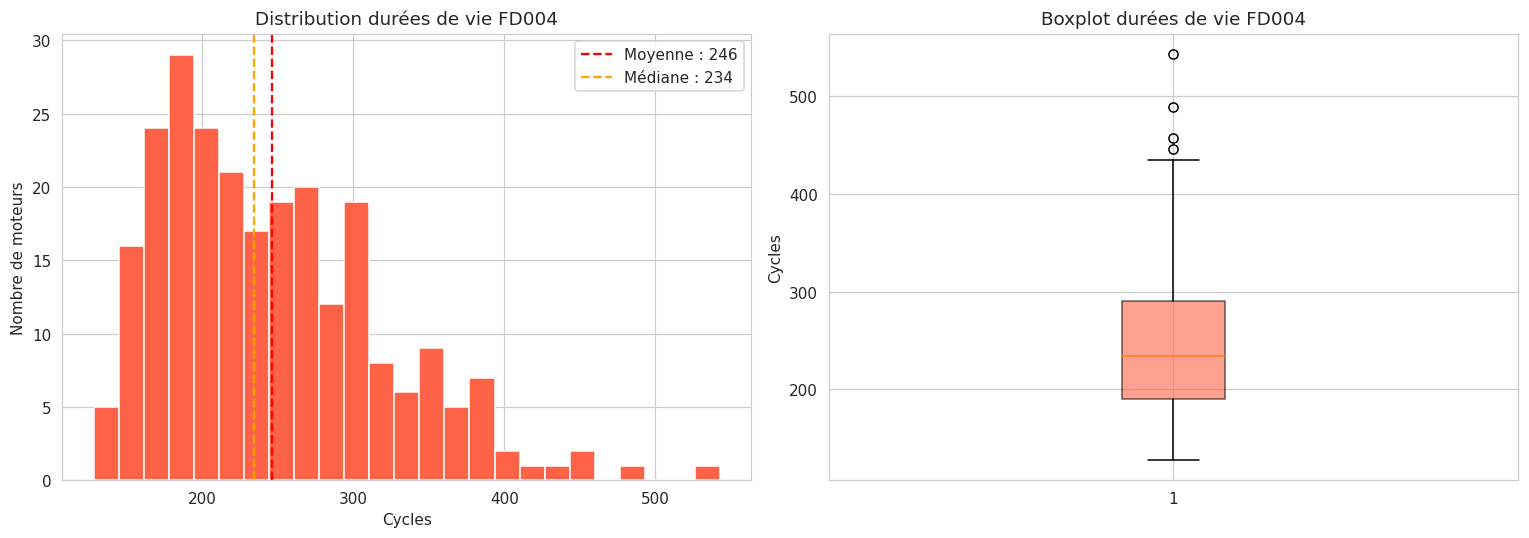


 Statistiques durées de vie FD004 :
count    249.0
mean     246.0
std       73.1
min      128.0
25%      190.0
50%      234.0
75%      290.0
max      543.0
Name: time_cycle, dtype: float64


In [5]:
lifetimes = df_train.groupby('unit_id')['time_cycle'].max()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(lifetimes, bins=25, color='tomato', edgecolor='white')
axes[0].axvline(lifetimes.mean(),   color='red',    linestyle='--',
                label=f'Moyenne : {lifetimes.mean():.0f}')
axes[0].axvline(lifetimes.median(), color='orange', linestyle='--',
                label=f'Médiane : {lifetimes.median():.0f}')
axes[0].set_title('Distribution durées de vie FD004', fontsize=12)
axes[0].set_xlabel('Cycles')
axes[0].set_ylabel('Nombre de moteurs')
axes[0].legend()

axes[1].boxplot(lifetimes, patch_artist=True,
                boxprops=dict(facecolor='tomato', alpha=0.6))
axes[1].set_title('Boxplot durées de vie FD004', fontsize=12)
axes[1].set_ylabel('Cycles')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fd004_lifetime_distribution.png', bbox_inches='tight')
plt.show()

print('\n Statistiques durées de vie FD004 :')
print(lifetimes.describe().round(1))

In [6]:
# Comparaison tous les datasets
print('=== Comparaison durées de vie — tous datasets ===')
print(f'FD001 : mean=206  std=46   min=128  max=362  (1 cond, 1 panne)')
print(f'FD002 : mean=?    std=?    min=?    max=?    (6 cond, 1 panne)')
print(f'FD003 : mean=?    std=?    min=?    max=?    (1 cond, 2 pannes)')
print(f'FD004 : mean={lifetimes.mean():.0f}  '
      f'std={lifetimes.std():.0f}  '
      f'min={lifetimes.min():.0f}  '
      f'max={lifetimes.max():.0f}  (6 cond, 2 pannes)')

=== Comparaison durées de vie — tous datasets ===
FD001 : mean=206  std=46   min=128  max=362  (1 cond, 1 panne)
FD002 : mean=?    std=?    min=?    max=?    (6 cond, 1 panne)
FD003 : mean=?    std=?    min=?    max=?    (1 cond, 2 pannes)
FD004 : mean=246  std=73  min=128  max=543  (6 cond, 2 pannes)


## 5. Calcul RUL + Clipping

In [7]:
# RUL train
max_cycles = df_train.groupby('unit_id')['time_cycle'].max().rename('max_cycle')
df_train   = df_train.merge(max_cycles, on='unit_id')
df_train['RUL'] = df_train['max_cycle'] - df_train['time_cycle']
df_train['RUL'] = df_train['RUL'].clip(upper=RUL_CAP)

# RUL test
test_max = df_test.groupby('unit_id')['time_cycle'].max().reset_index()
test_max.columns = ['unit_id', 'max_cycle_test']
df_test  = df_test.merge(test_max, on='unit_id')
df_rul['unit_id'] = range(1, len(df_rul) + 1)
df_test  = df_test.merge(df_rul, on='unit_id')
df_test['RUL'] = df_test['RUL_true'] + (df_test['max_cycle_test'] - df_test['time_cycle'])
df_test['RUL'] = df_test['RUL'].clip(upper=RUL_CAP)

pct = (df_train['RUL'] == RUL_CAP).mean() * 100
print(f' RUL calculé et plafonné à {RUL_CAP}')
print(f'{pct:.1f}% des lignes plafonnées à {RUL_CAP}')

 RUL calculé et plafonné à 125
49.2% des lignes plafonnées à 125


## 6. Feature Selection
**FD004 = 6 conditions → settings gardés comme FD002 → 17 features**

In [8]:
SETTING_COLS = ['op_setting_1', 'op_setting_2', 'op_setting_3']

# FD004 a 6 conditions → settings varient → on les GARDE
COLS_TO_DROP = SENSORS_TO_DROP + ['max_cycle', 'max_cycle_test', 'RUL_true']

df_train = df_train.drop(columns=[c for c in COLS_TO_DROP if c in df_train.columns])
df_test  = df_test.drop(columns=[c for c in COLS_TO_DROP if c in df_test.columns])

# Features = 14 capteurs + 3 settings = 17 (comme FD002)
FEATURE_COLS = SENSORS_TO_KEEP + SETTING_COLS
N_FEATURES   = len(FEATURE_COLS)

print(f'Feature cols ({N_FEATURES}) : {FEATURE_COLS}')
print(f'Shape train : {df_train.shape}')
print(f'Shape test  : {df_test.shape}')
print('\n💡 Settings gardés — FD004 a 6 conditions (comme FD002)')

Feature cols (17) : ['sensor_02', 'sensor_03', 'sensor_04', 'sensor_07', 'sensor_08', 'sensor_09', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'op_setting_1', 'op_setting_2', 'op_setting_3']
Shape train : (61249, 20)
Shape test  : (41214, 20)

💡 Settings gardés — FD004 a 6 conditions (comme FD002)


## 7. Normalisation — Scaler Global

In [9]:
scaler = MinMaxScaler(feature_range=(0, 1))

df_train[FEATURE_COLS] = scaler.fit_transform(df_train[FEATURE_COLS])
df_test[FEATURE_COLS]  = scaler.transform(df_test[FEATURE_COLS])

joblib.dump(scaler, f'{OUTPUT_DIR}/minmax_scaler_FD004.pkl')

print(' Scaler global appliqué et sauvegardé')
print('\nPlage après normalisation (train) :')
print(df_train[FEATURE_COLS].agg(['min','max']).T.round(3).head(5))

 Scaler global appliqué et sauvegardé

Plage après normalisation (train) :
           min  max
sensor_02  0.0  1.0
sensor_03  0.0  1.0
sensor_04  0.0  1.0
sensor_07  0.0  1.0
sensor_08  0.0  1.0


## 8. Fenêtres Glissantes (Window Size = 30)

In [10]:
def create_sequences(df, feature_cols, window_size=30):
    X_list, y_list = [], []
    for unit_id, group in df.groupby('unit_id'):
        data   = group[feature_cols].values
        labels = group['RUL'].values
        T = len(data)
        if T < window_size:
            pad    = np.repeat(data[[0]], window_size - T, axis=0)
            data   = np.vstack([pad, data])
            pad_y  = np.repeat(labels[0], window_size - T)
            labels = np.concatenate([pad_y, labels])
            T = window_size
        for t in range(T - window_size + 1):
            X_list.append(data[t : t + window_size])
            y_list.append(labels[t + window_size - 1])
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)


def create_test_sequences(df, feature_cols, window_size=30):
    X_list, y_list = [], []
    for unit_id, group in df.groupby('unit_id'):
        data   = group[feature_cols].values
        labels = group['RUL'].values
        T = len(data)
        if T < window_size:
            pad    = np.repeat(data[[0]], window_size - T, axis=0)
            data   = np.vstack([pad, data])
            labels = np.concatenate([np.repeat(labels[0], window_size - T), labels])
        X_list.append(data[-window_size:])
        y_list.append(labels[-1])
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)


print(f'Création des fenêtres (W={WINDOW_SIZE})...')
X_train_full, y_train_full = create_sequences(df_train, FEATURE_COLS, WINDOW_SIZE)
X_test,       y_test       = create_test_sequences(df_test, FEATURE_COLS, WINDOW_SIZE)

print(f' X_train_full : {X_train_full.shape}')
print(f' X_test       : {X_test.shape}')
print(f' y_train_full : {y_train_full.shape}')
print(f' y_test       : {y_test.shape}')

Création des fenêtres (W=30)...
 X_train_full : (54028, 30, 17)
 X_test       : (248, 30, 17)
 y_train_full : (54028,)
 y_test       : (248,)


## 9. Sauvegarder unit_ids + fichiers .npy

In [11]:
max_cycles_raw = df_train.groupby('unit_id')['time_cycle'].max()
unit_ids_per_seq = []
for uid, cnt in max_cycles_raw.items():
    n_seq = max(cnt - WINDOW_SIZE + 1, 1)
    unit_ids_per_seq.extend([uid] * n_seq)
unit_ids_per_seq = np.array(unit_ids_per_seq)

np.save(f'{OUTPUT_DIR}/X_train.npy',        X_train_full)
np.save(f'{OUTPUT_DIR}/y_train.npy',        y_train_full)
np.save(f'{OUTPUT_DIR}/X_test.npy',         X_test)
np.save(f'{OUTPUT_DIR}/y_test.npy',         y_test)
np.save(f'{OUTPUT_DIR}/unit_ids_train.npy', unit_ids_per_seq)

print('Fichiers sauvegardés :')
for name in ['X_train', 'y_train', 'X_test', 'y_test', 'unit_ids_train']:
    path = f'{OUTPUT_DIR}/{name}.npy'
    size = os.path.getsize(path) / 1024
    print(f'  {name}.npy  →  {size:.1f} KB')

Fichiers sauvegardés :
  X_train.npy  →  107634.0 KB
  y_train.npy  →  211.2 KB
  X_test.npy  →  494.2 KB
  y_test.npy  →  1.1 KB
  unit_ids_train.npy  →  422.2 KB


## 10. Sauvegarder le config FD004

In [12]:
config_fd004 = {
    'dataset':              'FD004',
    'sensors_to_keep':      SENSORS_TO_KEEP,
    'sensors_to_drop':      SENSORS_TO_DROP,
    'feature_cols':         FEATURE_COLS,
    'n_features':           N_FEATURES,
    'window_size':          WINDOW_SIZE,
    'rul_cap':              RUL_CAP,
    'n_train_engines':      df_train['unit_id'].nunique(),
    'n_test_engines':       df_test['unit_id'].nunique(),
    'operating_conditions': 6,
    'fault_modes':          2,
    'scaler':               'global_minmax',
    'note':                 'Settings gardés (6 conditions) + 2 modes de panne — dataset le plus difficile'
}

with open(f'{OUTPUT_DIR}/config_FD004.json', 'w') as f:
    json.dump(config_fd004, f, indent=2)

print(' Config FD004 sauvegardé')
print(json.dumps(config_fd004, indent=2))

 Config FD004 sauvegardé
{
  "dataset": "FD004",
  "sensors_to_keep": [
    "sensor_02",
    "sensor_03",
    "sensor_04",
    "sensor_07",
    "sensor_08",
    "sensor_09",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_17",
    "sensor_20",
    "sensor_21"
  ],
  "sensors_to_drop": [
    "sensor_01",
    "sensor_05",
    "sensor_06",
    "sensor_10",
    "sensor_16",
    "sensor_18",
    "sensor_19"
  ],
  "feature_cols": [
    "sensor_02",
    "sensor_03",
    "sensor_04",
    "sensor_07",
    "sensor_08",
    "sensor_09",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_17",
    "sensor_20",
    "sensor_21",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3"
  ],
  "n_features": 17,
  "window_size": 30,
  "rul_cap": 125,
  "n_train_engines": 249,
  "n_test_engines": 248,
  "operating_conditions": 6,
  "fault_modes": 2,
  "scaler": "global_minmax",
  "note": "Settings gard\u00e9

## 11. Résumé Final

In [13]:
print('=' * 60)
print(' RÉSUMÉ PREPROCESSING FD004')
print('=' * 60)
print(f'Moteurs train         : {df_train["unit_id"].nunique()}')
print(f'Moteurs test          : {df_test["unit_id"].nunique()}')
print(f'Features              : {N_FEATURES} (14 capteurs + 3 settings)')
print(f'Window size           : {WINDOW_SIZE}')
print(f'RUL cap               : {RUL_CAP}')
print(f'X_train shape         : {X_train_full.shape}')
print(f'X_test shape          : {X_test.shape}')
print(f'Conditions opérat.    : 6 (comme FD002)')
print(f'Modes de panne        : 2 (comme FD003)')
print(f'Scaler                : Global MinMax')
print(f'Settings              : gardés (varient)')
print('=' * 60)
print('\n📋 Récapitulatif tous les datasets :')
print(f'  FD001 → 14 features, 1 cond, 1 panne  ⭐')
print(f'  FD002 → 17 features, 6 cond, 1 panne  ⭐⭐')
print(f'  FD003 → 14 features, 1 cond, 2 pannes ⭐⭐')
print(f'  FD004 → 17 features, 6 cond, 2 pannes ⭐⭐⭐')
print(f'\n Preprocessing FD004 terminé !')
print(f' Fichiers dans : {OUTPUT_DIR}')


 RÉSUMÉ PREPROCESSING FD004
Moteurs train         : 249
Moteurs test          : 248
Features              : 17 (14 capteurs + 3 settings)
Window size           : 30
RUL cap               : 125
X_train shape         : (54028, 30, 17)
X_test shape          : (248, 30, 17)
Conditions opérat.    : 6 (comme FD002)
Modes de panne        : 2 (comme FD003)
Scaler                : Global MinMax
Settings              : gardés (varient)

📋 Récapitulatif tous les datasets :
  FD001 → 14 features, 1 cond, 1 panne  ⭐
  FD002 → 17 features, 6 cond, 1 panne  ⭐⭐
  FD003 → 14 features, 1 cond, 2 pannes ⭐⭐
  FD004 → 17 features, 6 cond, 2 pannes ⭐⭐⭐

 Preprocessing FD004 terminé !
 Fichiers dans : /content/drive/MyDrive/industrial-ai-platform/preprocessing_FD004
